# Modelo de recomendación inteligente de cultivos

Proyecto de machine learning para recomendar cultivos a partir de variables de suelo y clima usando Random Forest.


## 1. Importación de librerías


In [1]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Carga del dataset


In [2]:
DATA_PATH = Path("dataset") / "Crop_recommendation.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en {DATA_PATH.resolve()}. "
        "Verifica que Crop_recommendation.csv esté dentro de la carpeta dataset."
    )


In [3]:
df = pd.read_csv(DATA_PATH)


## 3. Revisión inicial del dataset


In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.shape

(2200, 8)

In [6]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

## 4. Separación de variables


In [8]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

## 5. División de datos en entrenamiento y prueba


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Entrenamiento del modelo Random Forest


In [10]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
print(f"Modelo entrenado: {modelo.n_estimators} árboles")
print(f"Número de características: {modelo.n_features_in_}")
print(f"Clases predichas: {modelo.classes_}")
print(f"Modelo listo para predecir: {modelo.get_params()['n_estimators']} árboles en el bosque")

Modelo entrenado: 100 árboles
Número de características: 7
Clases predichas: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
Modelo listo para predecir: 100 árboles en el bosque


## 7. Evaluación del modelo


In [11]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9955


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

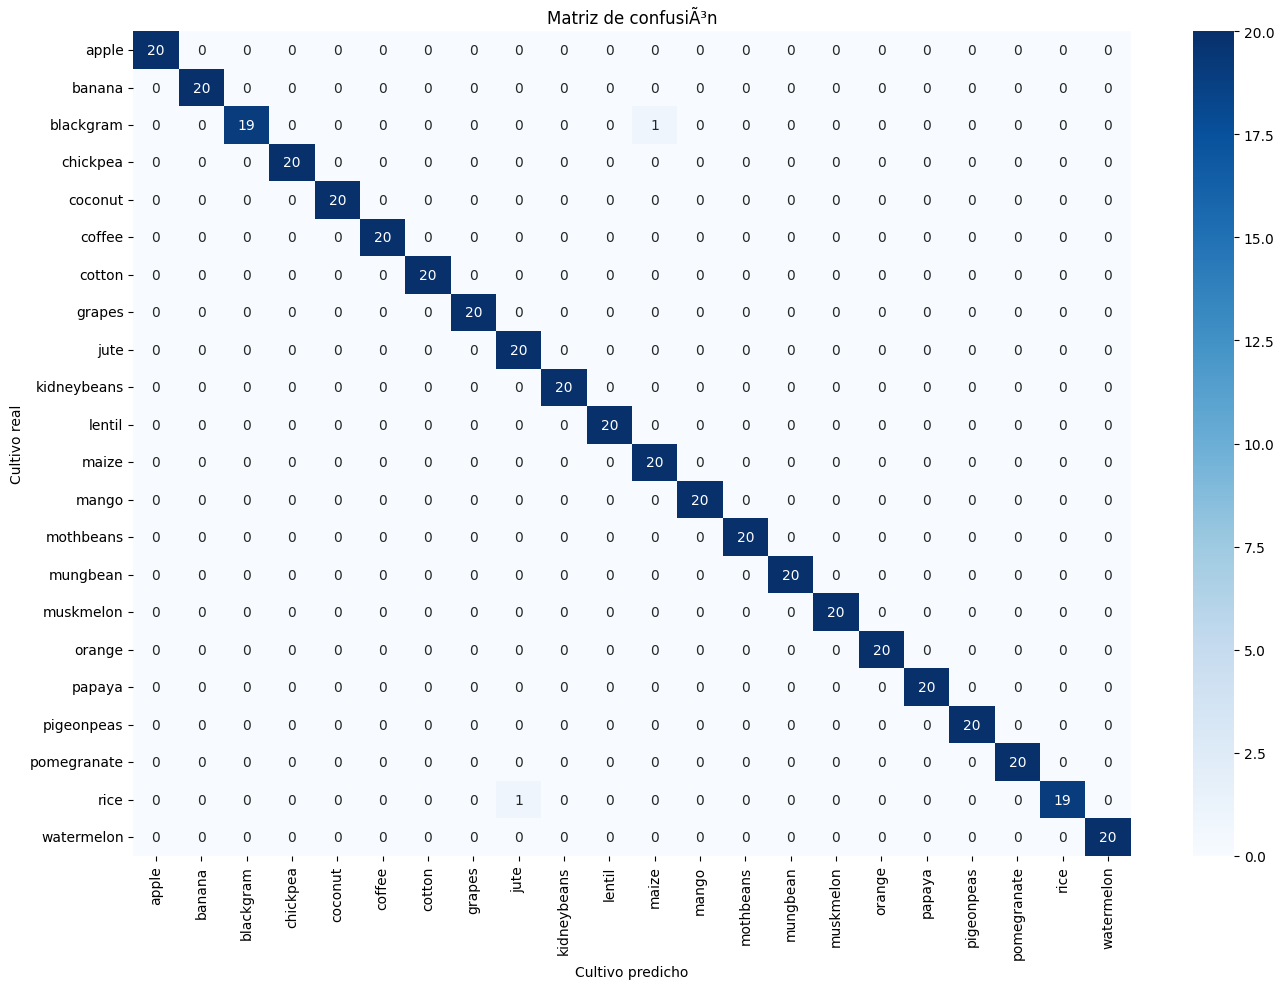

In [13]:
matriz = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=modelo.classes_,
    yticklabels=modelo.classes_,
    ax=ax
)
ax.set_xlabel('Cultivo predicho')
ax.set_ylabel('Cultivo real')
ax.set_title('Matriz de confusión')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Validación con un nuevo ejemplo


In [14]:
nuevo_ejemplo = pd.DataFrame({
    'N': [91],
    'P': [21],
    'K': [26],
    'temperature': [26.33377983],
    'humidity': [57.36469955],
    'ph': [7.261313694],
    'rainfall': [191.6549412]
})

cultivo_recomendado = modelo.predict(nuevo_ejemplo)[0]
print('Entrada: N=91, P=21, K=26, temperatura=26.33377983, humedad=57.36469955, ph=7.261313694, lluvia=191.6549412')
print(f'Cultivo recomendado: {cultivo_recomendado}')


Entrada: N=91, P=21, K=26, temperatura=26.33377983, humedad=57.36469955, ph=7.261313694, lluvia=191.6549412
Cultivo recomendado: coffee
